<a href="https://colab.research.google.com/github/josethomas568/BGG-Regression-Analysis/blob/main/BGG_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BOARD GAME DATA ANALYSIS
## GOAL : Perform exploratory data analysis and predictive modeling (Analyze the board game data set from Board Game Geeks and predict average rating)
## MODELS USED : Linear Regression(Baseline), Ridge Regression, Lasso Regression, Random Forest, Gradient Forest
## Target Variable : Average Rating


# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV, LeaveOneOut

# Load Data (bgg_data)

In [ ]:

# Load Data
bgg_data = pd.read_csv('<FILE PATH>')

# Basic Info of the data

In [ ]:
# Basic Info

print(bgg_data.describe())

                  ID  Year Published   Min Players   Max Players  \
count   20322.000000    20322.000000  20322.000000  20322.000000   
mean   108238.469344     2003.739789      2.022193      5.559000   
std     98684.013416       37.700650      0.685426      9.290747   
min         1.000000     1000.000000      1.000000      1.000000   
25%     11028.500000     2001.000000      2.000000      4.000000   
50%     88958.500000     2011.000000      2.000000      4.000000   
75%    192946.500000     2016.000000      2.000000      6.000000   
max    331787.000000     2023.000000     10.000000    362.000000   

          Play Time       Min Age   Users Rated  Rating Average      BGG Rank  \
count  20322.000000  20322.000000  2.032200e+04    20322.000000  20322.000000   
mean      92.967572     10.262081 -1.090883e-16        6.403436      8.920917   
std      267.497623      2.825121  1.000025e+00        0.935790      0.996932   
min       30.000000      1.000000 -1.202172e+00        1.050000

## Discriptive statistics for numeric features

In [ ]:
# Discriptive statistics
nc = ['Owned Users', 'Users Rated', 'Rating Average', 'Complexity Average']
print("Descriptive Statistics:")
print(bgg_data[nc].describe())

Descriptive Statistics:
         Owned Users    Users Rated  Rating Average  Complexity Average
count   20322.000000   20322.000000    20322.000000        20322.000000
mean     1408.604911     841.703917        6.403436            2.030910
std      5039.948508    3513.296862        0.935790            0.802731
min         3.000000      30.000000        1.050000            1.000000
25%       146.000000      55.000000        5.820000            1.330000
50%       309.000000     120.000000        6.430000            2.000000
75%       865.000000     385.000000        7.030000            2.570000
max    155312.000000  102214.000000        9.580000            5.000000


# Exploratory Data Analysis
## Distribution of Rating Average

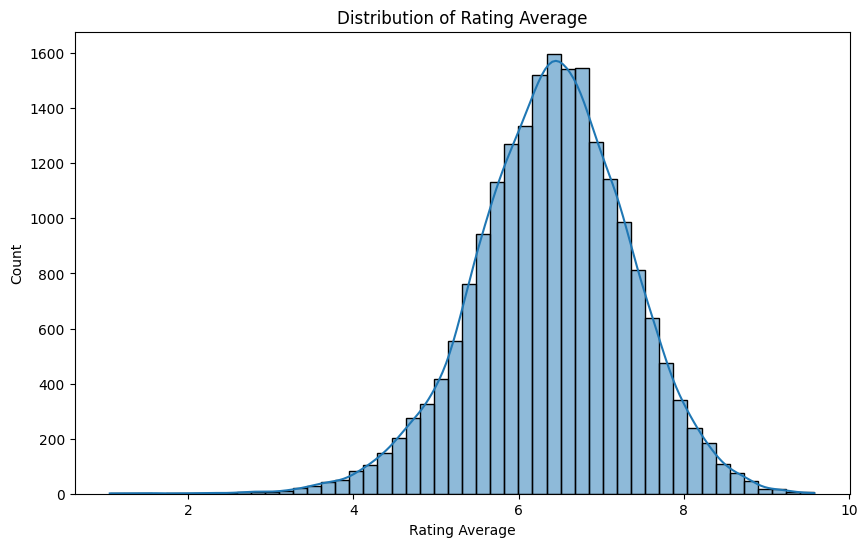

In [ ]:
# Distribution of Rating Average
plt.figure(figsize=(10,6))
sns.histplot(bgg_data['Rating Average'].dropna(), bins=50, kde=True)
plt.title('Distribution of Rating Average')
plt.xlabel('Rating Average')
plt.ylabel('Count')
plt.show()

## Complexity Average Distribution

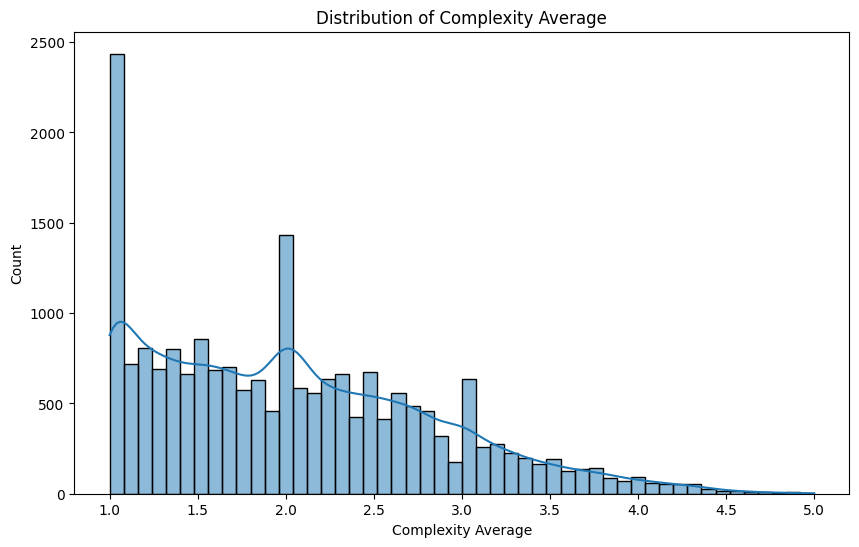

In [ ]:
# Complexity Average Distribution
plt.figure(figsize=(10,6))
sns.histplot(bgg_data['Complexity Average'].dropna(), bins=50, kde=True)
plt.title('Distribution of Complexity Average')
plt.xlabel('Complexity Average')
plt.ylabel('Count')
plt.show()

## Users Rated Distribution

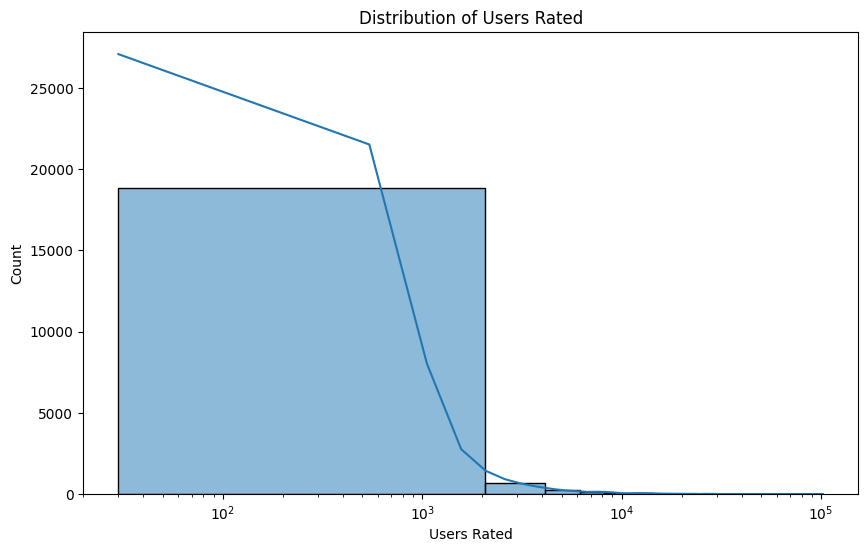

In [ ]:
# Users Rated Distribution
plt.figure(figsize=(10,6))
sns.histplot(bgg_data['Users Rated'].dropna(), bins=50, kde=True)
plt.title('Distribution of Users Rated')
plt.xlabel('Users Rated')
plt.ylabel('Count')
plt.xscale('log')
plt.show()


## # Scatter plot: Complexity Average vs Rating Average

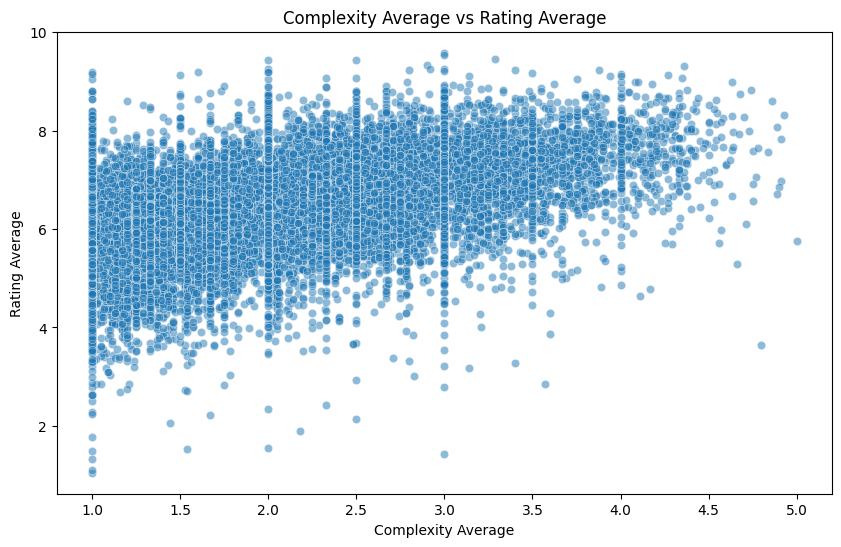

In [ ]:
# Complexity Average vs Rating Average
plt.figure(figsize=(10,6))
sns.scatterplot(data=bgg_data, x='Complexity Average', y='Rating Average', alpha=0.5)
plt.title('Complexity Average vs Rating Average')
plt.xlabel('Complexity Average')
plt.ylabel('Rating Average')
plt.show()

## Scatter plot: User ratings vs Rating Average

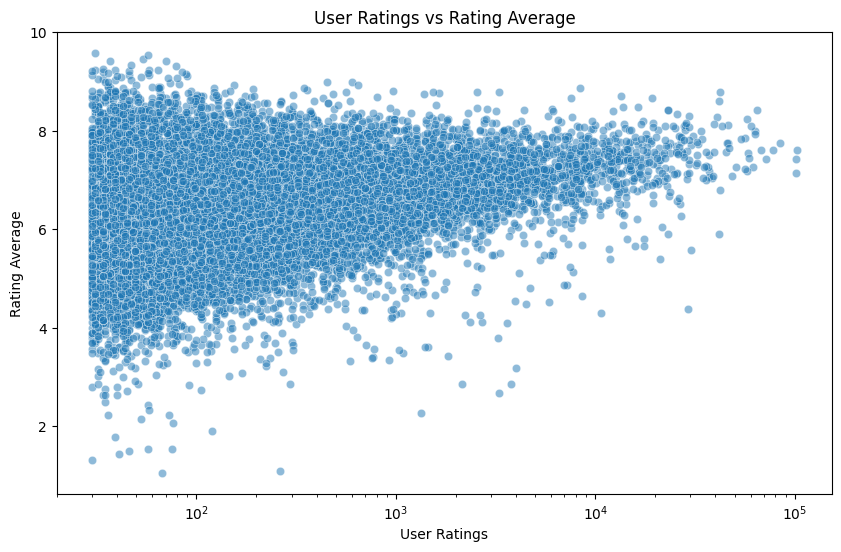

In [ ]:
# User ratings vs Rating Average
plt.figure(figsize=(10,6))
sns.scatterplot(data=bgg_data, x='Users Rated', y='Rating Average', alpha=0.5)
plt.title('User Ratings vs Rating Average')
plt.xlabel('User Ratings')
plt.ylabel('Rating Average')
plt.xscale('log')
plt.show()

## Correlation Matrix

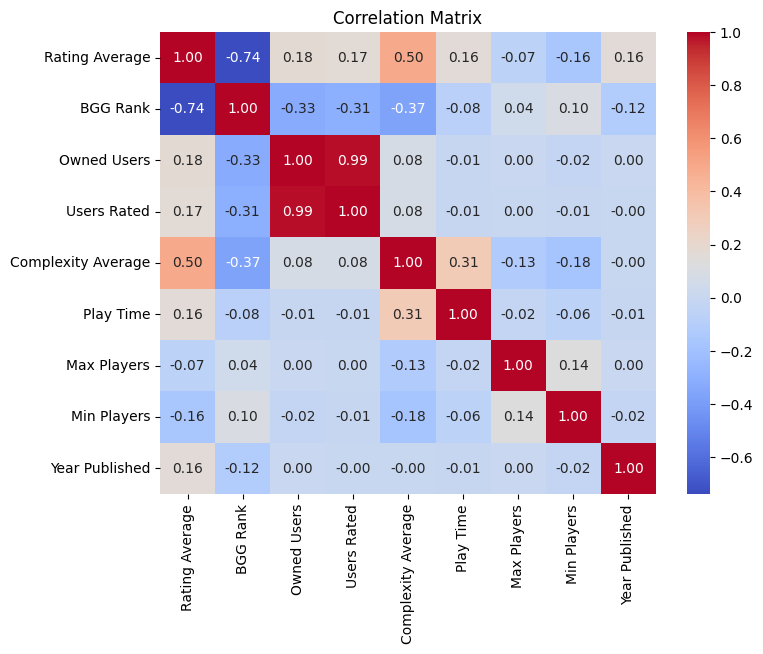

In [ ]:
# Correlation Matrix
corr = bgg_data[['Rating Average','BGG Rank', 'Owned Users', 'Users Rated', 'Complexity Average', 'Play Time', 'Max Players', 'Min Players', 'Year Published']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

## Lineplot of Mean Rating Average per Year

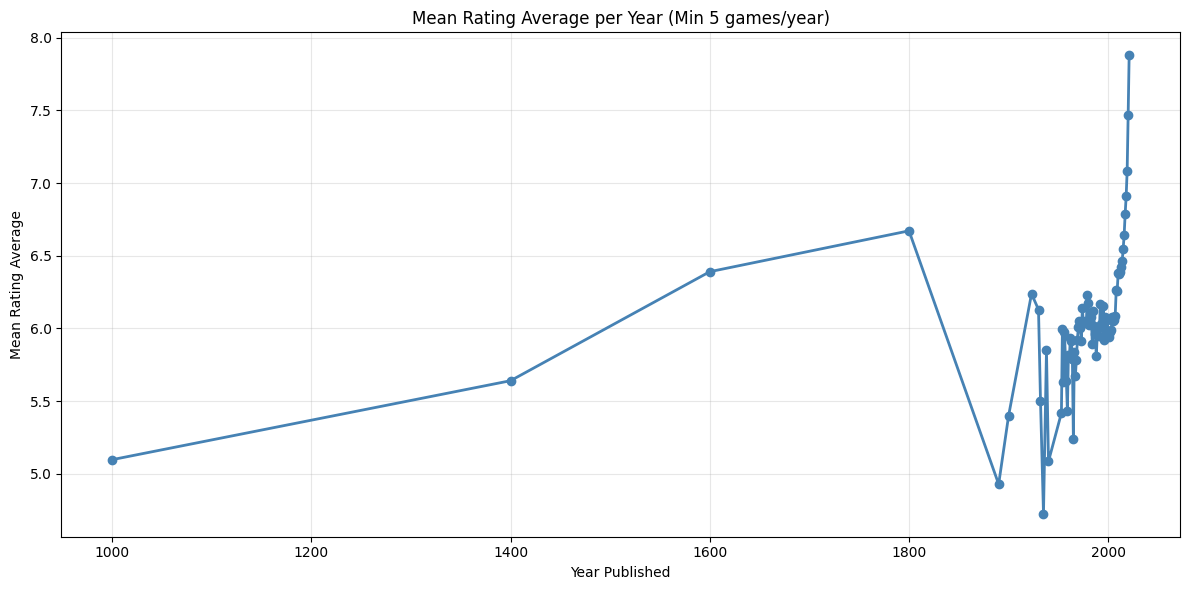

In [ ]:
# Lineplot of Mean Rating Average per Year (with minimum sample size filter)
plt.figure(figsize=(12,6))
year_count = bgg_data.groupby('Year Published').size()
thresh_year = year_count[year_count >= 5].index  # minimum 5 games per year
ry = bgg_data[bgg_data['Year Published'].isin(thresh_year)].groupby('Year Published')['Rating Average'].mean()
plt.plot(ry.index, ry.values, marker='o', linewidth=2, markersize=6, color='steelblue')
plt.title('Mean Rating Average per Year (Min 5 games/year)')
plt.xlabel('Year Published')
plt.ylabel('Mean Rating Average')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Lineplot of Mean Complexity Average per Year

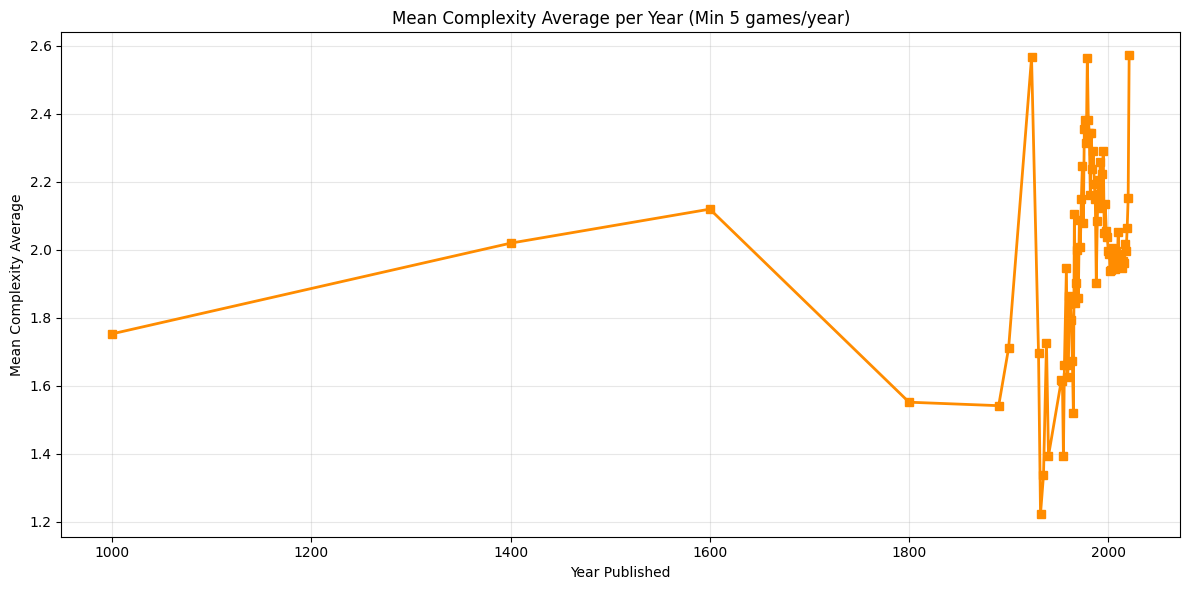

In [ ]:
# Lineplot of Mean Complexity Average per Year
plt.figure(figsize=(12,6))
cy = bgg_data[bgg_data['Year Published'].isin(thresh_year)].groupby('Year Published')['Complexity Average'].mean()
plt.plot(cy.index, cy.values, marker='s', linewidth=2, markersize=6, color='darkorange')
plt.title('Mean Complexity Average per Year (Min 5 games/year)')
plt.xlabel('Year Published')
plt.ylabel('Mean Complexity Average')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Barplot for Min Players (Mean Average Rating)

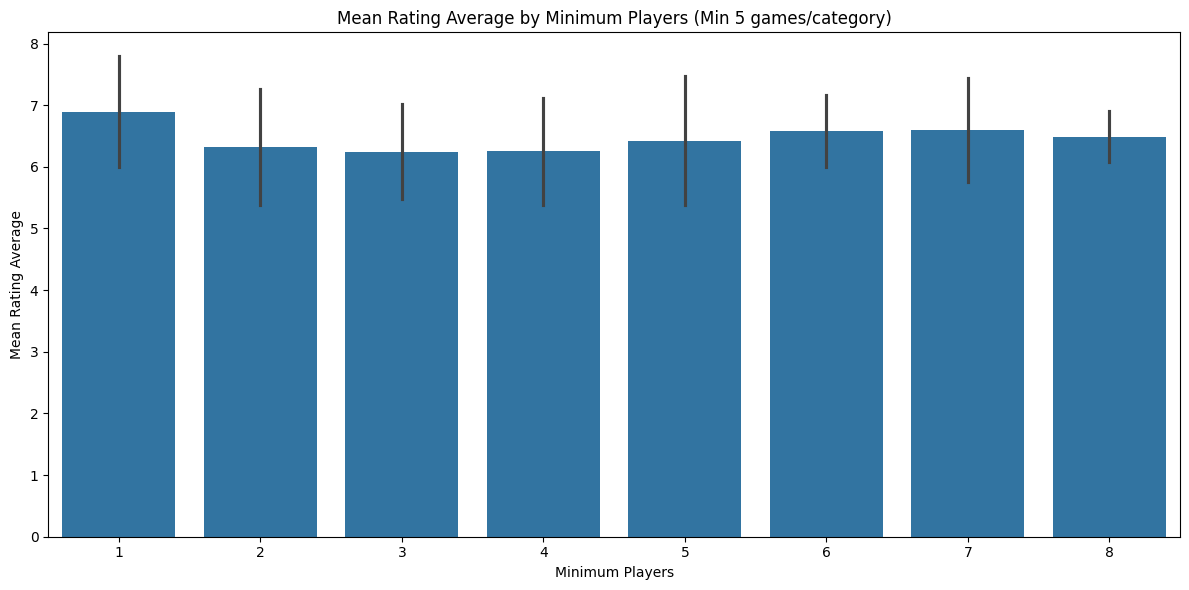

In [ ]:
# Barplot for Min Players
plt.figure(figsize=(12, 6))
mip_counts = bgg_data['Min Players'].value_counts()
mip = mip_counts[mip_counts >= 5].index
bp_mip = bgg_data[bgg_data['Min Players'].isin(mip)]
sns.barplot(data=bp_mip, x="Min Players", y="Rating Average", estimator=np.mean, errorbar='sd')
plt.title("Mean Rating Average by Minimum Players (Min 5 games/category)")
plt.xlabel("Minimum Players")
plt.ylabel("Mean Rating Average")
plt.tight_layout()
plt.show()

## Barplot for Max Players (Mean Average Rating)

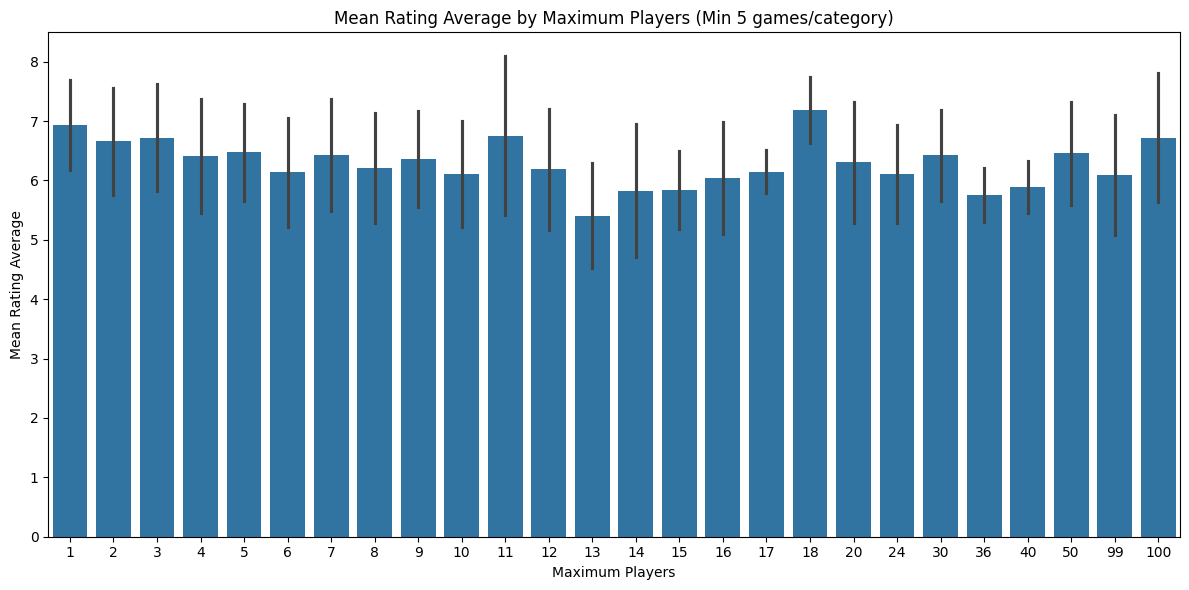

In [ ]:
# Barplot for Max Players
plt.figure(figsize=(12, 6))
mp_count = bgg_data['Max Players'].value_counts()
mp = mp_count[mp_count >= 5].index
bp_max = bgg_data[bgg_data['Max Players'].isin(mp)]
sns.barplot(data=bp_max, x="Max Players", y="Rating Average", estimator=np.mean, errorbar='sd')
plt.title("Mean Rating Average by Maximum Players (Min 5 games/category)")
plt.xlabel("Maximum Players")
plt.ylabel("Mean Rating Average")
plt.tight_layout()
plt.show()

## Barplot for Min Age (Mean Average Rating)

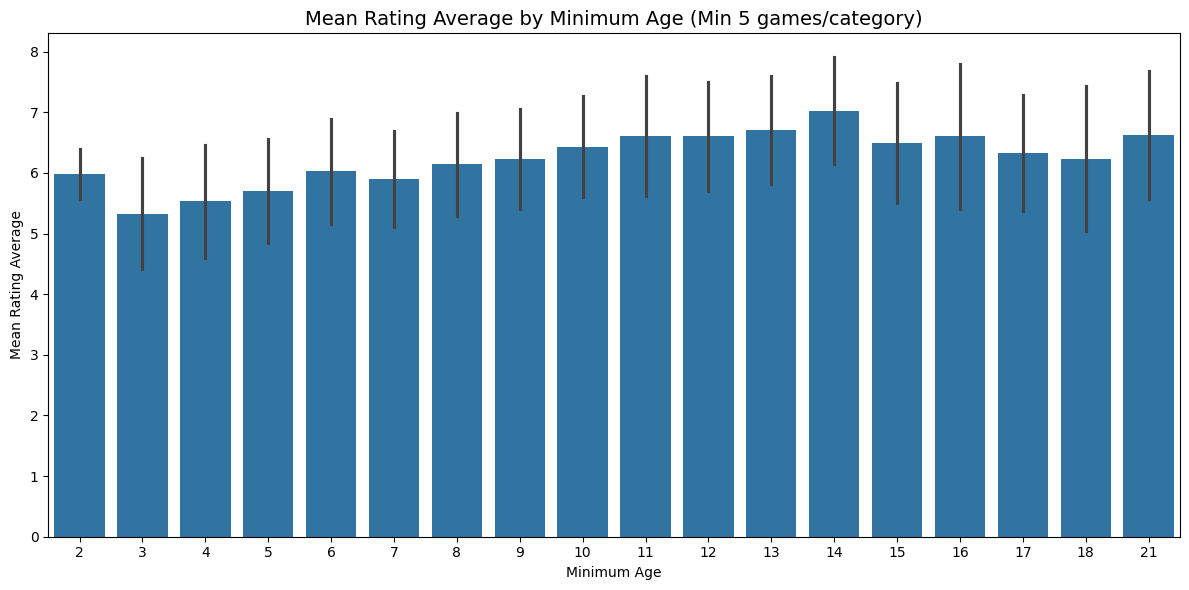

In [ ]:
# Barplot for Min Age (mean Rating Average)
plt.figure(figsize=(12, 6))
ma_counts = bgg_data['Min Age'].value_counts()
ma = ma_counts[ma_counts >= 5].index
bp_ma = bgg_data[bgg_data['Min Age'].isin(ma)]
sns.barplot(data=bp_ma, x="Min Age", y="Rating Average", estimator=np.mean, errorbar='sd')
plt.title("Mean Rating Average by Minimum Age (Min 5 games/category)", fontsize=14)
plt.xlabel("Minimum Age")
plt.ylabel("Mean Rating Average")
plt.tight_layout()
plt.show()

## Barplot for Play Time

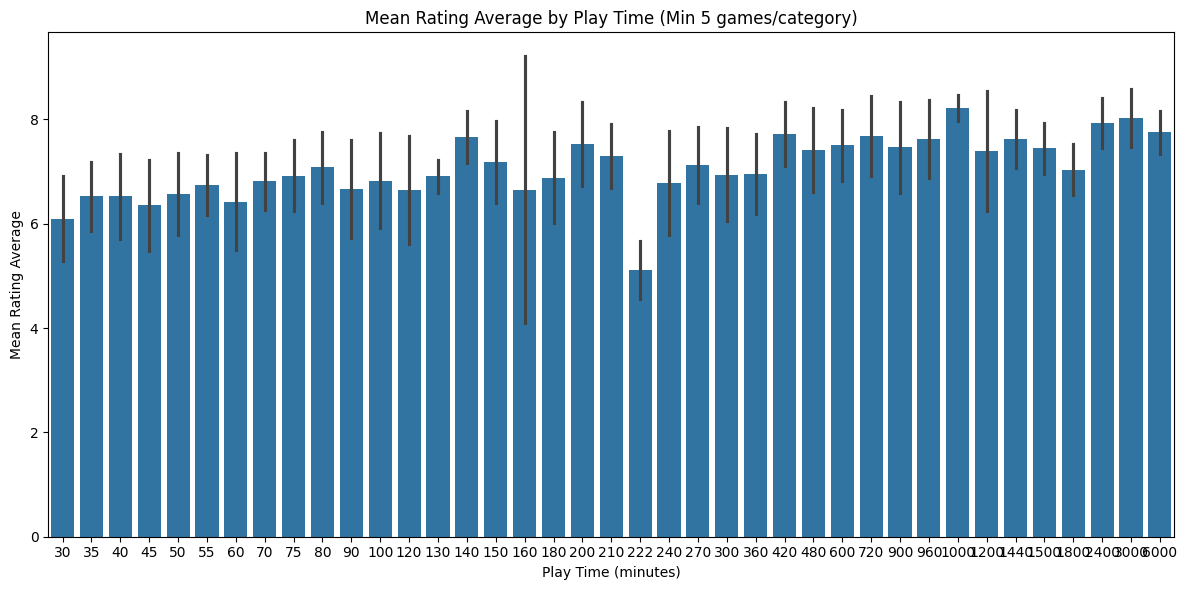

In [ ]:
# Barplot for Play Time
plt.figure(figsize=(12, 6))
pt_counts = bgg_data['Play Time'].value_counts()
pt = pt_counts[pt_counts >= 5].index
bp_pt = bgg_data[bgg_data['Play Time'].isin(pt)]
sns.barplot(data=bp_pt, x="Play Time", y="Rating Average", estimator=np.mean, errorbar='sd')
plt.title("Mean Rating Average by Play Time (Min 5 games/category)")
plt.xlabel("Play Time (minutes)")
plt.ylabel("Mean Rating Average")
plt.tight_layout()
plt.show()

# Average Ratings vs Owned Users(log scale)

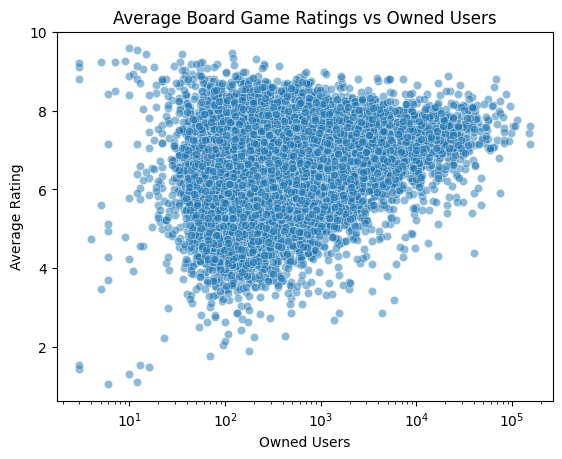

In [ ]:
# Average Ratings vs Owned Users
sns.scatterplot(data=bgg_data, x="Owned Users", y="Rating Average", alpha=0.5)
plt.xscale('log')
plt.title("Average Board Game Ratings vs Owned Users")
plt.xlabel("Owned Users")
plt.ylabel("Average Rating")
plt.show()

## Barplot of Top 15 Mechanics ()

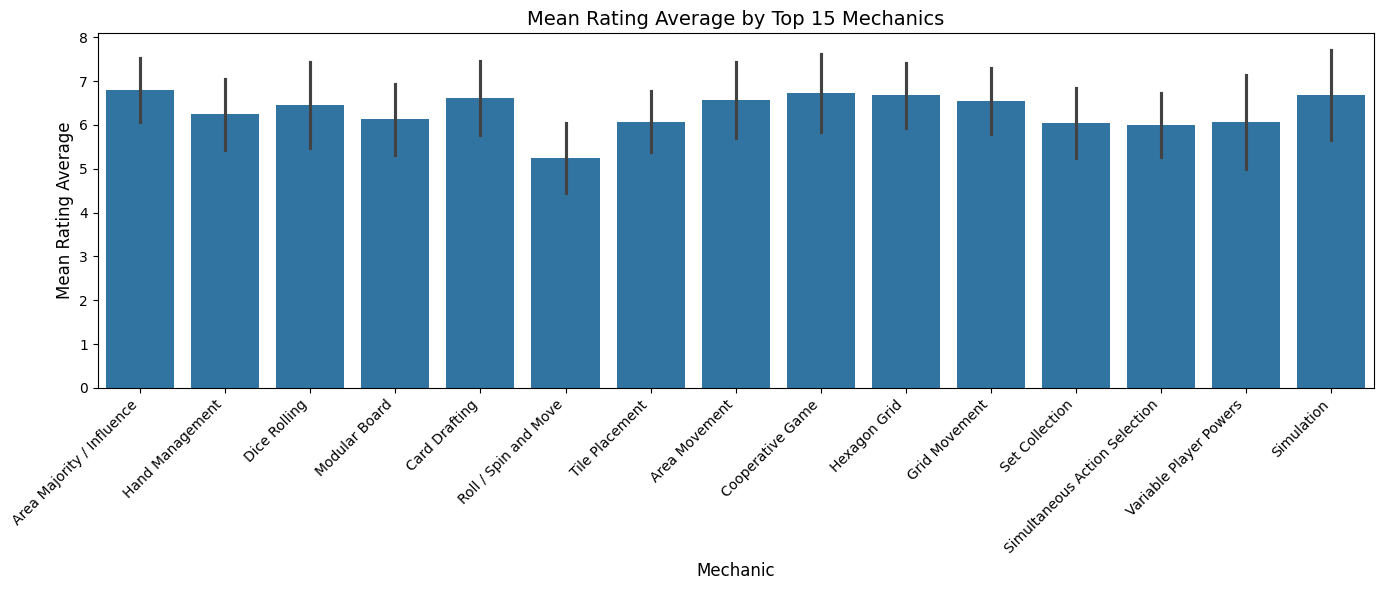

In [ ]:
# Barplot of Top 15 Mechanics
mech_series = bgg_data['Mechanics'].dropna().astype(str).str.replace(';', ',', regex=False)
mech_items = mech_series.str.split(',').explode().str.strip()
tm = mech_items.value_counts().head(15).index

bgg_data['Mechanics_first'] = bgg_data['Mechanics'].fillna('').str.split(',|;').str[0].str.strip()
mech = bgg_data[bgg_data['Mechanics_first'].isin(tm)]
plt.figure(figsize=(14, 6))
sns.barplot(data=mech, x="Mechanics_first", y="Rating Average", estimator=np.mean, errorbar='sd')
plt.title("Mean Rating Average by Top 15 Mechanics", fontsize=14)
plt.xlabel("Mechanic", fontsize=12)
plt.ylabel("Mean Rating Average", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Barplot of Top 15 Domains ()

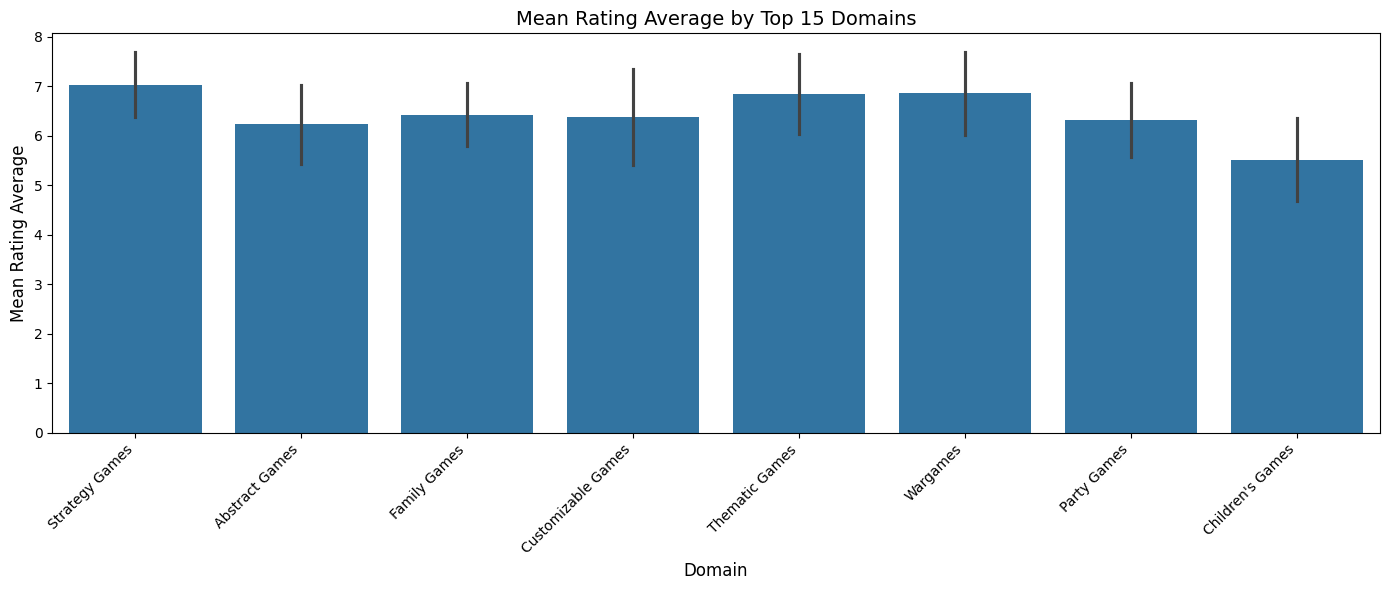

In [ ]:
# Barplot of Top 15 Domains
dom_series = bgg_data['Domains'].dropna().astype(str).str.replace(';', ',', regex=False)
dom_items = dom_series.str.split(',').explode().str.strip()
td = dom_items.value_counts().head(15).index

bgg_data['Domains_first'] = bgg_data['Domains'].fillna('').str.split(',|;').str[0].str.strip()
dom = bgg_data[bgg_data['Domains_first'].isin(td)]
plt.figure(figsize=(14, 6))
sns.barplot(data=dom, x="Domains_first", y="Rating Average", estimator=np.mean, errorbar='sd')
plt.title("Mean Rating Average by Top 15 Domains", fontsize=14)
plt.xlabel("Domain", fontsize=12)
plt.ylabel("Mean Rating Average", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# Pairplot for numeric predictors (Rank, Complexity Average, Owned Users, Play Time, Rating Average)

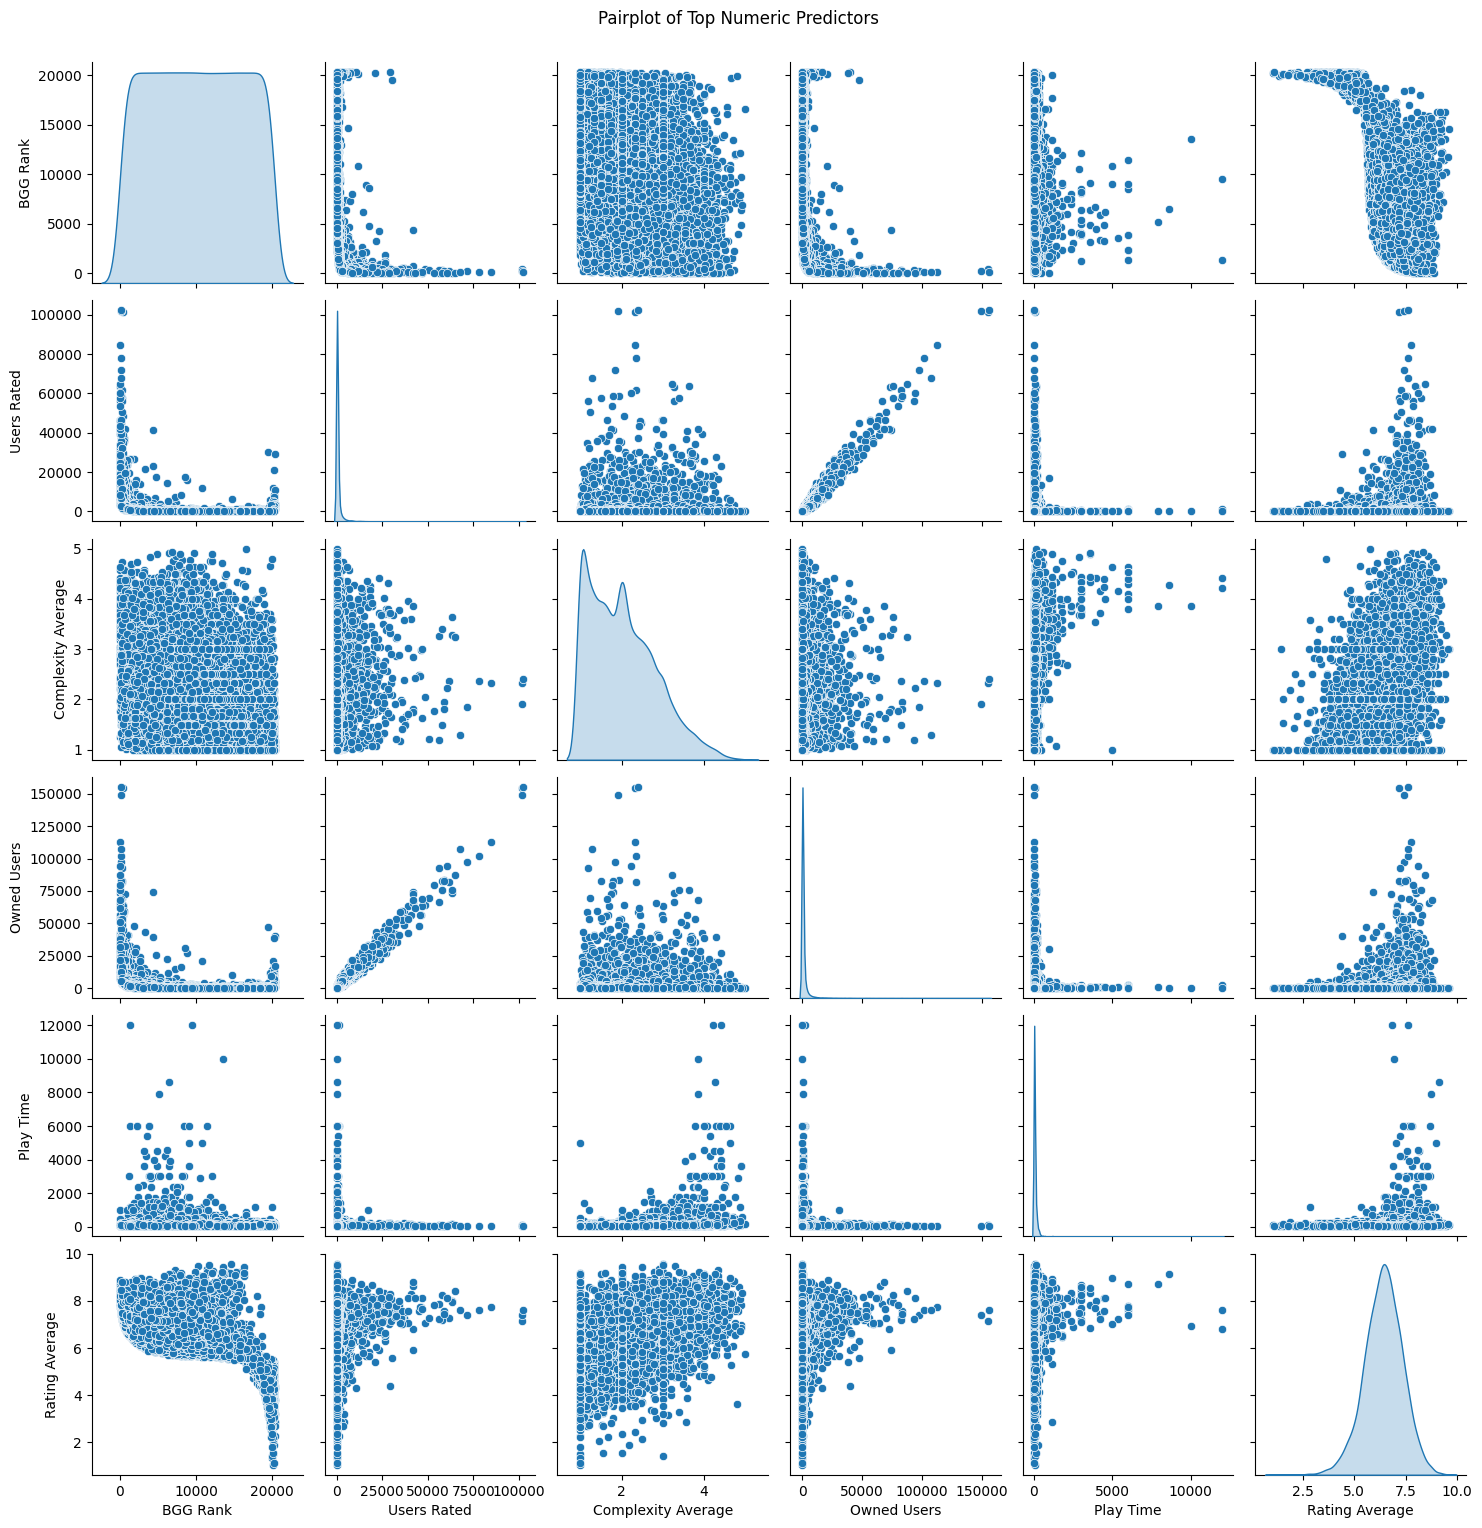

In [ ]:
# Pairplot
pp = ['BGG Rank', 'Users Rated', 'Complexity Average', 'Owned Users', 'Play Time', 'Rating Average']
pp= [col for col in pp if col in bgg_data.columns]
sns.pairplot(bgg_data[pp], diag_kind='kde')
plt.suptitle('Pairplot of Top Numeric Predictors', y=1.02)
plt.show()

# Preprocessing
## Multi-Hot Encoding

In [ ]:
# Feature Engineering
def multi_hot(df, col, top_n=20):
    # Get all items (split on ',' or ';')
    items = df[col].dropna().astype(str).str.replace(';', ',').str.split(',')
    all_items = [i.strip() for sublist in items for i in sublist]
    top = pd.Series(all_items).value_counts().head(top_n).index
    # Create columns
    for mech in top:
        df[f"{col}_{mech}"] = df[col].fillna('').apply(lambda x: int(mech in str(x)))
    return df, list(top)
# Mechanics
if 'Mechanics' in bgg_data:
    bgg_data, top_mech = multi_hot(bgg_data, 'Mechanics', top_n=20)
    print("Top Mechanics : ",top_mech)
# Domains
if 'Domains' in bgg_data:
    bgg_data, top_dom = multi_hot(bgg_data, 'Domains', top_n=8)
    print("Top Domains : ", top_dom)


Top Mechanics :  ['Dice Rolling', 'Hand Management', 'Set Collection', 'Variable Player Powers', 'Hexagon Grid', 'Simulation', 'Card Drafting', 'Tile Placement', 'Modular Board', 'Area Majority / Influence', 'Grid Movement', 'Cooperative Game', 'Roll / Spin and Move', 'Area Movement', 'Simultaneous Action Selection', 'Action Points', 'Auction/Bidding', 'Take That', 'Team-Based Game', 'Memory']
Top Domains :  ['Wargames', 'Strategy Games', 'Family Games', 'Thematic Games', 'Abstract Games', "Children's Games", 'Party Games', 'Customizable Games']


## Data Type Correction

In [ ]:
# Ensuring numeric columns are numeric
for c in ['Owned Users', 'Users Rated', 'BGG Rank', 'Play Time', 'Max Players', 'Min Players', 'Year Published']:
    if c in bgg_data.columns:
        bgg_data[c] = pd.to_numeric(bgg_data[c], errors='coerce')

## Log Transformation

In [ ]:
# Log Transform Users Rated and BGG Rank
for col in ['Users Rated', 'BGG Rank']:
    if col in bgg_data.columns:
        bgg_data[col] = bgg_data[col].apply(lambda x: np.log1p(x) if pd.notnull(x) and x > 0 else 0)
        print(f"Log-transformed {col}")

Log-transformed Users Rated
Log-transformed BGG Rank


## Standardizing

In [ ]:
# Standardize
scaler = StandardScaler()
num_for_scaler = [c for c in ['Owned Users', 'Users Rated', 'Complexity Average'] if c in bgg_data.columns]
if num_for_scaler:
    bgg_data[num_for_scaler] = scaler.fit_transform(bgg_data[num_for_scaler])

# Data Preparation

In [ ]:
# Prepare X and Y fro modeling
X = bgg_data.drop(columns = ['Name', 'ID', 'Owned Users', 'Rating Average', 'Mechanics', 'Domains', 'Mechanics_list', 'Domains_list'])
y = bgg_data['Rating Average']
X = X.select_dtypes(include=[np.number])
X = X.apply(pd.to_numeric, errors='coerce')
imputer = SimpleImputer(strategy='mean')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

## Train-test split

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=6375)

# Model Fitting (With Rank as a feature)
## Baseline Model: Linear Regression

In [ ]:
# Baseline Model: Linear Regression
bl_model = LinearRegression()
bl_model.fit(X_train, y_train)
y_baseline_pred = bl_model.predict(X_test)
print("Baseline Model Evaluation:")
print("Mean Absolute Error:", mean_absolute_error(y_test, y_baseline_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_baseline_pred))
print("R^2 Score:", r2_score(y_test, y_baseline_pred))
print("Cross-Validation Scores (R^2):", cross_val_score(bl_model, X, y, cv=5))

Baseline Model Evaluation:
Mean Absolute Error: 0.39940744945347556
Mean Squared Error: 0.3432546870301622
R^2 Score: 0.6211568456782883
Cross-Validation Scores (R^2): [0.49335478 0.54336965 0.63858833 0.554626   0.15144138]


## Feature Importance (Linear Regression)

Baseline Feature Importances:
                                    Feature  Importance
6                                  BGG Rank    1.010411
5                               Users Rated    0.630349
20           Mechanics_Roll / Spin and Move    0.325686
29                   Domains_Strategy Games    0.263978
35               Domains_Customizable Games    0.260338
34                      Domains_Party Games    0.208510
7                        Complexity Average    0.191973
25                      Mechanics_Take That    0.164746
30                     Domains_Family Games    0.151568
19               Mechanics_Cooperative Game    0.125533
31                   Domains_Thematic Games    0.123532
12                   Mechanics_Hexagon Grid    0.106326
23                  Mechanics_Action Points    0.087518
28                         Domains_Wargames    0.079469
33                 Domains_Children's Games    0.078973
8                    Mechanics_Dice Rolling    0.078336
11         Mechani

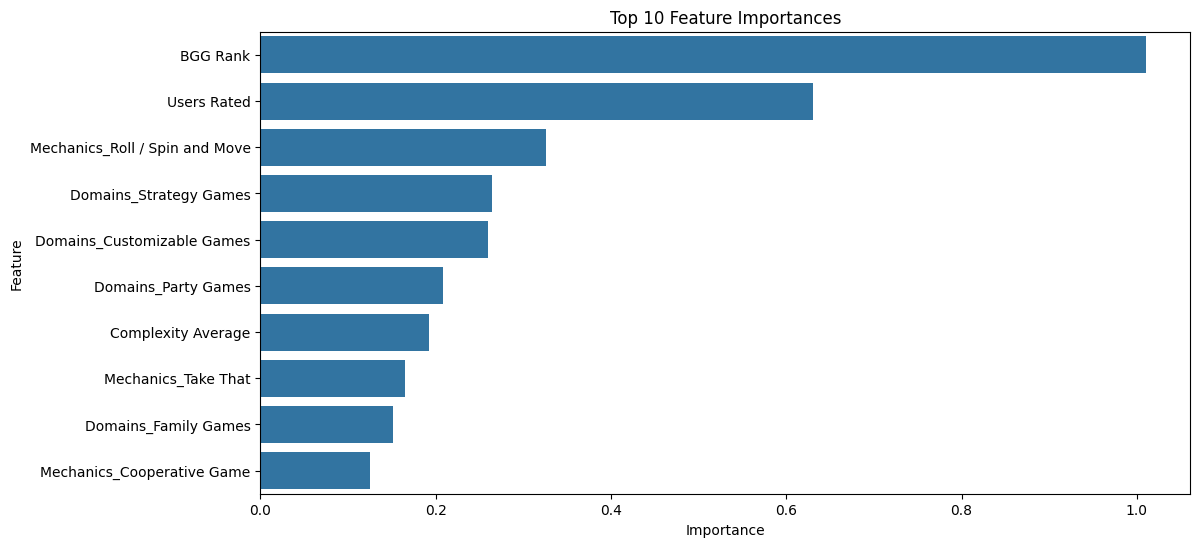

In [ ]:
# Baseline Feature Importance
bl_importances = np.abs(bl_model.coef_)
feat_names = X.columns
bl_feat_importance = pd.DataFrame({'Feature': feat_names, 'Importance': bl_importances})
bl_feat_importance = bl_feat_importance.sort_values(by='Importance', ascending=False)
print("Baseline Feature Importances:")
print(bl_feat_importance)
plt.figure(figsize=(12,6))
sns.barplot(data=bl_feat_importance.head(10), x='Importance', y='Feature')
plt.title('Top 10 Feature Importances')
plt.show()

# Cross-Validation

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=6375)
cv_score_bm = cross_val_score(bl_model, X, y, cv=kf)
print("K-Fold Cross-Validation Scores (R^2):", cv_score_bm)

K-Fold Cross-Validation Scores (R^2): [0.62115685 0.62421553 0.61730942 0.63085109 0.61832731]


## Ridge Regression

In [ ]:
# Model Training (Ridge Regression)
# Impute missing values
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)
ridge_model = Ridge()
ridge_model.fit(X_imputed, y_train)

# Model Evaluation for Ridge
y_ridge_pred = ridge_model.predict(X_test_imputed)
print("Ridge Model Evaluation:")
print("Mean Absolute Error:", mean_absolute_error(y_test, y_ridge_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_ridge_pred))
print("R^2 Score:", r2_score(y_test, y_ridge_pred))
print("Cross-Validation Scores (R^2):", cross_val_score(ridge_model, X_imputed, y_train, cv=5))

Ridge Model Evaluation:
Mean Absolute Error: 0.3994062318906369
Mean Squared Error: 0.343277182395654
R^2 Score: 0.6211320180050108
Cross-Validation Scores (R^2): [0.62535681 0.63083474 0.60160696 0.63943587 0.6138033 ]


## Feature Importance(Ridge Regression)

Ridge Feature Importances:
                                    Feature  Importance
6                                  BGG Rank    1.009983
5                               Users Rated    0.629934
20           Mechanics_Roll / Spin and Move    0.325449
29                   Domains_Strategy Games    0.263716
35               Domains_Customizable Games    0.259216
34                      Domains_Party Games    0.207927
7                        Complexity Average    0.191968
25                      Mechanics_Take That    0.164527
30                     Domains_Family Games    0.151331
19               Mechanics_Cooperative Game    0.125481
31                   Domains_Thematic Games    0.123403
12                   Mechanics_Hexagon Grid    0.106037
23                  Mechanics_Action Points    0.087414
28                         Domains_Wargames    0.079379
33                 Domains_Children's Games    0.079002
8                    Mechanics_Dice Rolling    0.078318
11         Mechanics_

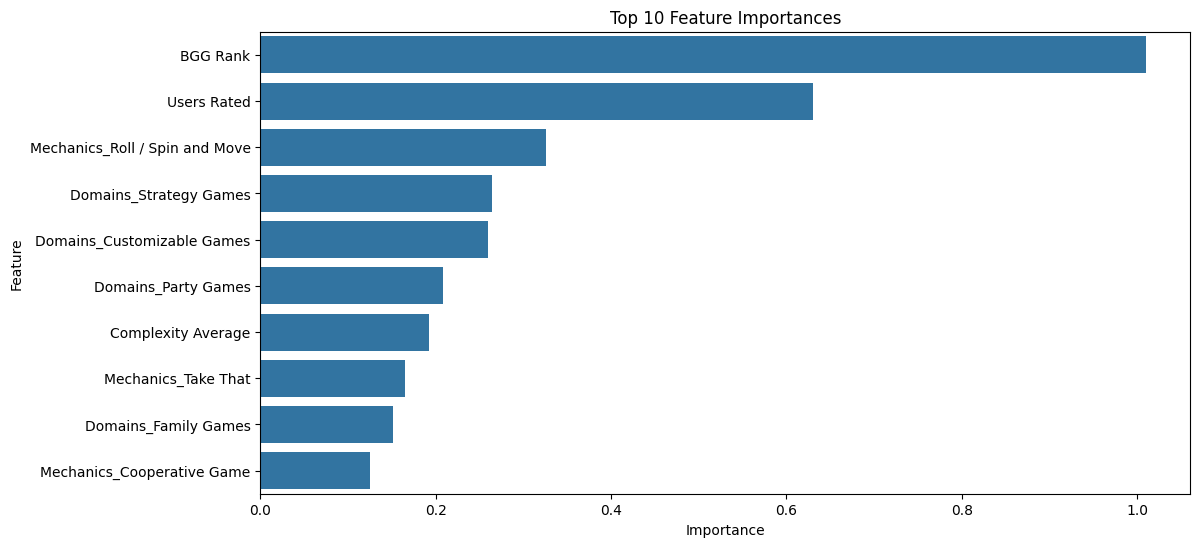

In [ ]:
# Feature Importance for Ridge
ridge_importances = np.abs(ridge_model.coef_)
ridge_feat_importance = pd.DataFrame({'Feature': feat_names, 'Importance': ridge_importances})
ridge_feat_importance = ridge_feat_importance.sort_values(by='Importance', ascending=False)
print("Ridge Feature Importances:")
print(ridge_feat_importance)
plt.figure(figsize=(12,6))
sns.barplot(data=ridge_feat_importance.head(10), x='Importance', y='Feature')
plt.title('Top 10 Feature Importances')
plt.show()

## Lasso Regression

In [ ]:
# Model Training (Lasso Regression)
lasso_model = Lasso()
lasso_model.fit(X_imputed, y_train)

# Model Evaluation for Lasso
y_lasso_pred = lasso_model.predict(X_test_imputed)
print("Lasso Model Evaluation : ")
print("Mean Absolute Error : ", mean_absolute_error(y_test, y_lasso_pred))
print("Mean Squared Error : ", mean_squared_error(y_test, y_lasso_pred))
print("R^2 Score : ", r2_score(y_test, y_lasso_pred))
print("Cross-Validation Scores (R^2) : ", cross_val_score(lasso_model, X_imputed, y_train, cv=5))

Lasso Model Evaluation : 
Mean Absolute Error :  0.7207065366368032
Mean Squared Error :  0.8664729254169136
R^2 Score :  0.04369161266409616
Cross-Validation Scores (R^2) :  [0.04054837 0.04805777 0.05849517 0.05771409 0.05417354]


## Feature Importance (Lasso Regression)

Lasso Feature Importances:
                                    Feature  Importance
0                            Year Published    0.003698
3                                 Play Time    0.000504
27                         Mechanics_Memory    0.000000
21                  Mechanics_Area Movement    0.000000
22  Mechanics_Simultaneous Action Selection    0.000000
23                  Mechanics_Action Points    0.000000
24                Mechanics_Auction/Bidding    0.000000
25                      Mechanics_Take That    0.000000
26                Mechanics_Team-Based Game    0.000000
28                         Domains_Wargames    0.000000
19               Mechanics_Cooperative Game    0.000000
29                   Domains_Strategy Games    0.000000
30                     Domains_Family Games    0.000000
31                   Domains_Thematic Games    0.000000
32                   Domains_Abstract Games    0.000000
33                 Domains_Children's Games    0.000000
34                   

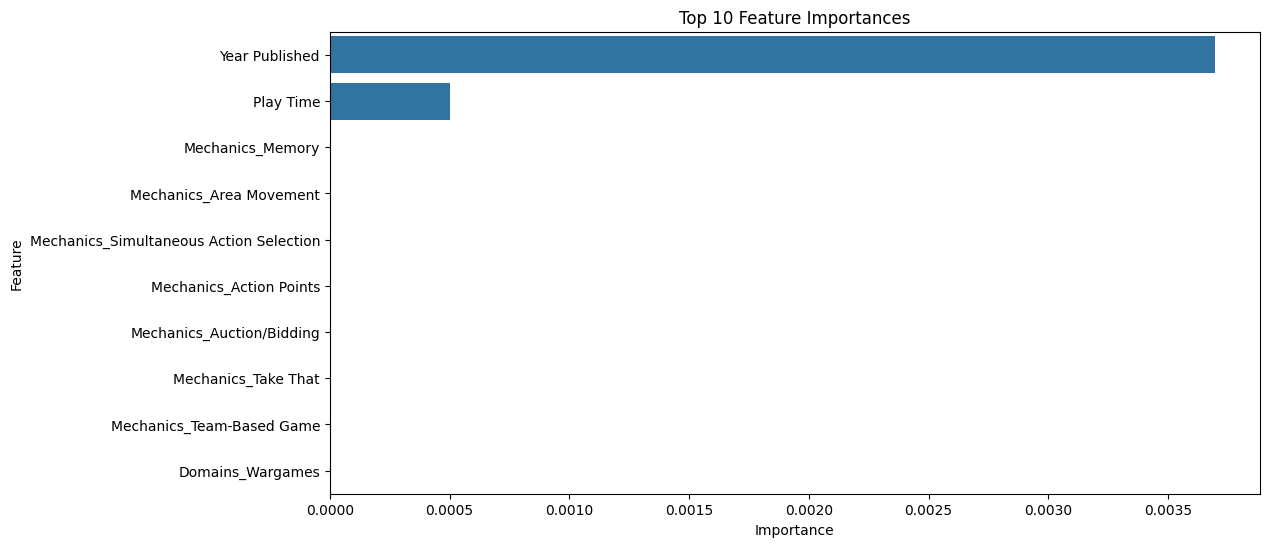

In [ ]:
# Feature Importance for Lasso
lasso_importance= np.abs(lasso_model.coef_)
lasso_feat_importance = pd.DataFrame({'Feature': feat_names, 'Importance': lasso_importance})
lasso_feat_importance = lasso_feat_importance.sort_values(by='Importance', ascending=False)
print("Lasso Feature Importances:")
print(lasso_feat_importance)
plt.figure(figsize=(12,6))
sns.barplot(data=lasso_feat_importance.head(10), x='Importance', y='Feature')
plt.title('Top 10 Feature Importances')
plt.show()

## Random Forest

In [ ]:
# Model Training (Random Forest)
rf = RandomForestRegressor(random_state=6375)
# Parameter grid for GridSearchCV
para_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}
rf_grid = GridSearchCV(rf, para_grid_rf, cv=5, n_jobs=-1, scoring='r2')
rf_grid.fit(X_train, y_train)
# best estimator by grid search
rf = rf_grid.best_estimator_
print("Best RandomForest params:", rf_grid.best_params_)

# Random Forest model with best parameters
rfbest = rf_grid.best_estimator_
rfbest.fit(X_train, y_train)
# Model Evaluation
y_pred = rfbest.predict(X_test)
print("Model Evaluation:")
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R^2 Score:", r2_score(y_test, y_pred))
print("Cross-Validation Scores (R^2):", cross_val_score(rfbest, X, y, cv=5))

Best RandomForest params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Model Evaluation:
Mean Absolute Error: 0.2271455842558426
Mean Squared Error: 0.12126223850430506
R^2 Score: 0.8661653557230351
Cross-Validation Scores (R^2): [0.86769045 0.89208511 0.87169575 0.80739738 0.6004082 ]


## Feature Importance (Random Forest)

Feature Importances:
                                    Feature  Importance
6                                  BGG Rank    0.476421
0                            Year Published    0.113844
7                        Complexity Average    0.106909
5                               Users Rated    0.071487
3                                 Play Time    0.041661
4                                   Min Age    0.035834
2                               Max Players    0.020323
1                               Min Players    0.019700
20           Mechanics_Roll / Spin and Move    0.016014
28                         Domains_Wargames    0.009893
8                    Mechanics_Dice Rolling    0.007785
11         Mechanics_Variable Player Powers    0.007489
29                   Domains_Strategy Games    0.007218
13                     Mechanics_Simulation    0.006150
9                 Mechanics_Hand Management    0.004422
12                   Mechanics_Hexagon Grid    0.004288
33                 Domains_

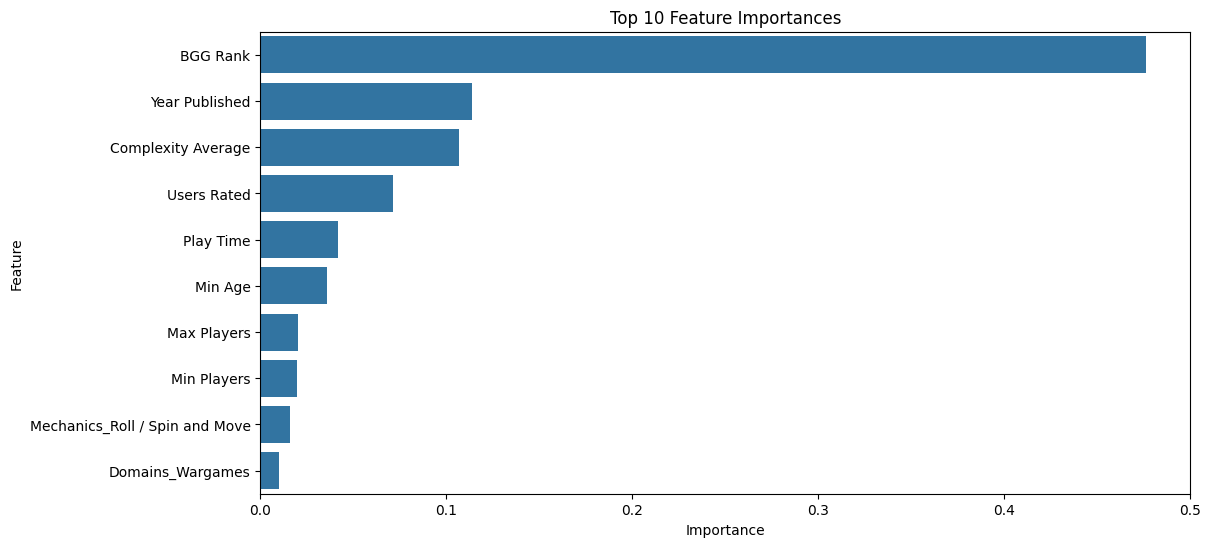

In [ ]:
# Feature Importance
feat_names = list(X.columns)
imp = rfbest.feature_importances_
feat_importance = pd.DataFrame({'Feature': feat_names, 'Importance': imp})
feat_importance = feat_importance.sort_values(by='Importance', ascending=False)
print("Feature Importances:")
print(feat_importance)
plt.figure(figsize=(12,6))
sns.barplot(data=feat_importance.head(10), x='Importance', y='Feature')
plt.title('Top 10 Feature Importances')
plt.show()

## Gradient Boosting

In [ ]:
# Model Training (Gradient Boosting)
gb_model = HistGradientBoostingRegressor(random_state=6375)

# Grid Search for Hyperparameter Tuning
para_grid_gb = {
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5, 10],
    'min_samples_leaf': [20, 50],
    'max_iter': [100, 200]
}
gb_grid = GridSearchCV(gb_model, para_grid_gb, cv=5, n_jobs=-1, scoring='r2')
gb_grid.fit(X_train, y_train)
# Best estimator by grid search
gb_model = gb_grid.best_estimator_
print("Best Gradient Boosting params:", gb_grid.best_params_)
# Gradient Boosting model with best parameters
gb_model_best = gb_grid.best_estimator_
gb_model_best.fit(X_train, y_train)
# Model Evaluation for Gradient Boosting
y_gb_pred = gb_model_best.predict(X_test)
print("Gradient Boosting Model Evaluation:")
print("Mean Absolute Error:", mean_absolute_error(y_test, y_gb_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_gb_pred))
print("R^2 Score:", r2_score(y_test, y_gb_pred))
print("Cross-Validation Scores (R^2):", cross_val_score(gb_model, X, y, cv=5))


Best Gradient Boosting params: {'learning_rate': 0.1, 'max_depth': 10, 'max_iter': 200, 'min_samples_leaf': 20}
Gradient Boosting Model Evaluation:
Mean Absolute Error: 0.12697895238090243
Mean Squared Error: 0.053263809720884396
R^2 Score: 0.9412138262103958
Cross-Validation Scores (R^2): [0.96645046 0.96899902 0.95716479 0.91219546 0.80580003]


## Feature Importance for Gradient Boosting

Gradient Boosting Feature Importances:
                                    Feature  Importance
6                                  BGG Rank    3.016995
5                               Users Rated    1.131923
0                            Year Published    0.027524
7                        Complexity Average    0.007931
3                                 Play Time    0.002128
25                      Mechanics_Take That    0.001344
8                    Mechanics_Dice Rolling    0.001161
2                               Max Players    0.001065
11         Mechanics_Variable Player Powers    0.001033
19               Mechanics_Cooperative Game    0.000967
29                   Domains_Strategy Games    0.000723
16                  Mechanics_Modular Board    0.000484
1                               Min Players    0.000438
28                         Domains_Wargames    0.000399
18                  Mechanics_Grid Movement    0.000366
13                     Mechanics_Simulation    0.000323
4        

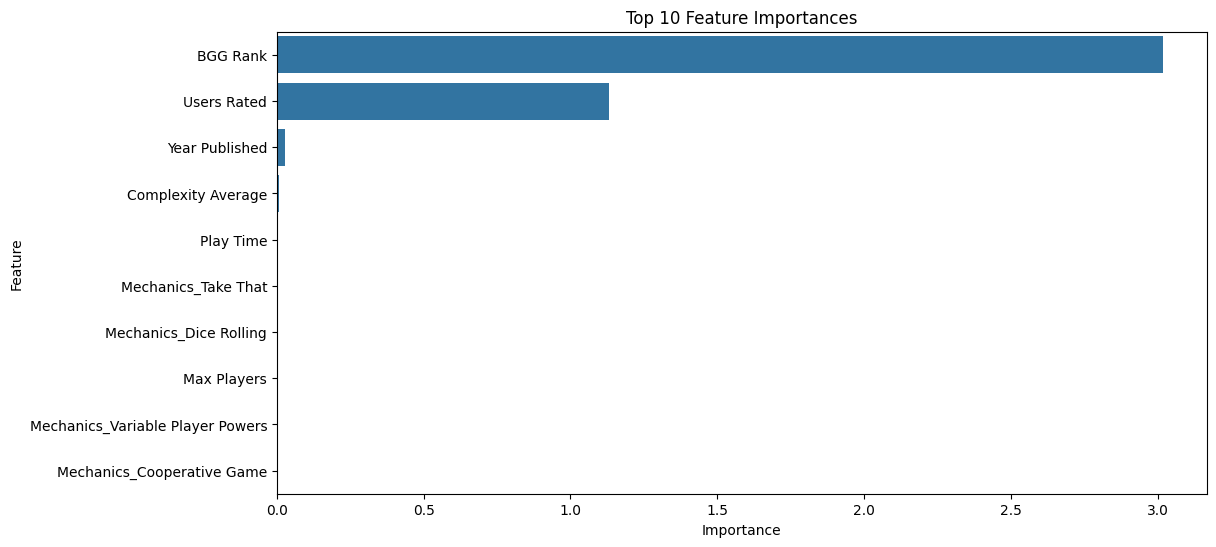

In [ ]:
# Feature Importance for Gradient Boosting
perm_result = permutation_importance(gb_model_best, X_test, y_test, n_repeats=10, random_state=6375, n_jobs=-1)
gb_feat_importance = pd.DataFrame({'Feature': feat_names, 'Importance': perm_result.importances_mean})
gb_feat_importance = gb_feat_importance.sort_values(by='Importance', ascending=False)
print("Gradient Boosting Feature Importances:")
print(gb_feat_importance)
plt.figure(figsize=(12,6))
sns.barplot(data=gb_feat_importance.head(10), x='Importance', y='Feature')
plt.title('Top 10 Feature Importances')
plt.show()

# Model Comparison

Model Comparison Summary:
Baseline Linear Regression - Mean R^2: 0.4763, Std: 0.1690
Random Forest - Mean R^2: 0.8079, Std: 0.1075
Ridge Regression - Mean R^2: 0.6222, Std: 0.0132
Lasso Regression - Mean R^2: 0.0518, Std: 0.0067
Gradient Boosting - Mean R^2: 0.9221, Std: 0.0617


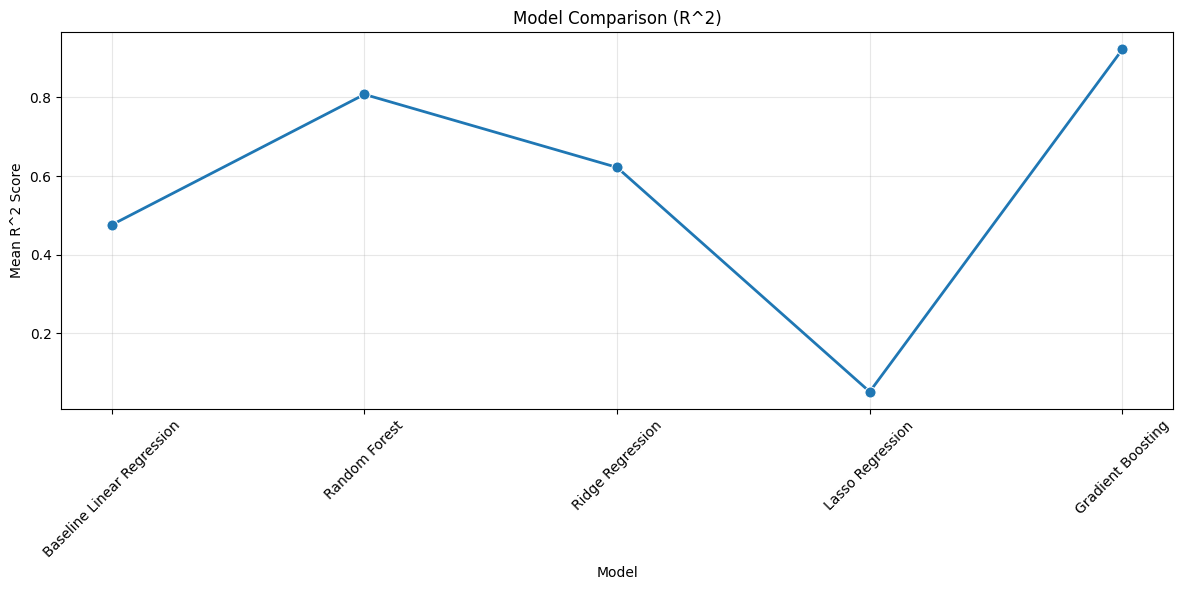

In [ ]:
# Model Comparison
def compare_models(models, X, y, X_imputed=None, y_train=None, cv=5):
    model_names = []
    mean_r2_scores = []
    std_r2_scores = []

    print("Model Comparison Summary:")
    for name, model in models.items():
        # Using imputed data for Ridge/Lasso, original data for others
        if name in ['Ridge Regression', 'Lasso Regression']:
            X_eval = X_imputed
            y_eval = y_train
        else:
            X_eval = X
            y_eval = y

        scores = cross_val_score(model, X_eval, y_eval, cv=cv)
        model_names.append(name)
        mean_r2_scores.append(np.mean(scores))
        std_r2_scores.append(np.std(scores))
        print(f"{name} - Mean R^2: {np.mean(scores):.4f}, Std: {np.std(scores):.4f}")

    # Creating DataFrame for visualization
    model_comp_df = pd.DataFrame({
        'Model': model_names,
        'Mean R^2': mean_r2_scores,
        'Std R^2': std_r2_scores
    })

    return model_comp_df

# Visualize model comparison
def model_comp_graph(model_comp_df):
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=model_comp_df, x='Model', y='Mean R^2', marker='o', linewidth=2, markersize=8)
    plt.title('Model Comparison (R^2)')
    plt.xlabel('Model')
    plt.ylabel('Mean R^2 Score')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# model dictionary
models = {
    'Baseline Linear Regression': bl_model,
    'Random Forest': rfbest,
    'Ridge Regression': ridge_model,
    'Lasso Regression': lasso_model,
    'Gradient Boosting': gb_model_best
}

# Compare models
model_comp = compare_models(models, X, y, X_imputed=X_imputed, y_train=y_train, cv=5)

# Plot comparison
model_comp_graph(model_comp)

# Data Preparation (Removing Rank as a feature)

In [ ]:
# Prepare X and Y for modeling
X = bgg_data.drop(columns = ['Name', 'ID', 'Owned Users','BGG Rank', 'Rating Average', 'Mechanics', 'Domains', 'Mechanics_list', 'Domains_list'])
y = bgg_data['Rating Average']
X = X.select_dtypes(include=[np.number])
X = X.apply(pd.to_numeric, errors='coerce')
imputer = SimpleImputer(strategy='mean')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

## Train-test split

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=6375)

# Model Fitting (Without Rank)
## Baseline Model: Linear Regression

In [ ]:
# Baseline Model: Linear Regression
bl_model = LinearRegression()
bl_model.fit(X_train, y_train)
y_baseline_pred = bl_model.predict(X_test)
print("Baseline Model Evaluation:")
print("Mean Absolute Error:", mean_absolute_error(y_test, y_baseline_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_baseline_pred))
print("R^2 Score:", r2_score(y_test, y_baseline_pred))
print("Cross-Validation Scores (R^2):", cross_val_score(bl_model, X, y, cv=5))

Baseline Model Evaluation:
Mean Absolute Error: 0.5690128727400875
Mean Squared Error: 0.5812317401291243
R^2 Score: 0.35850645557808214
Cross-Validation Scores (R^2): [ 0.09102272  0.28201094  0.34431225  0.33076389 -0.43018647]


## Feature Importance (Linear Regression)

Baseline Feature Importances:
                                    Feature  Importance
19           Mechanics_Roll / Spin and Move    0.565277
34               Domains_Customizable Games    0.400610
6                        Complexity Average    0.356795
18               Mechanics_Cooperative Game    0.276478
32                 Domains_Children's Games    0.264805
30                   Domains_Thematic Games    0.195473
5                               Users Rated    0.192946
24                      Mechanics_Take That    0.153965
10         Mechanics_Variable Player Powers    0.153799
25                Mechanics_Team-Based Game    0.123080
23                Mechanics_Auction/Bidding    0.115476
12                     Mechanics_Simulation    0.114640
20                  Mechanics_Area Movement    0.102930
22                  Mechanics_Action Points    0.100251
13                  Mechanics_Card Drafting    0.089278
11                   Mechanics_Hexagon Grid    0.088406
7                 

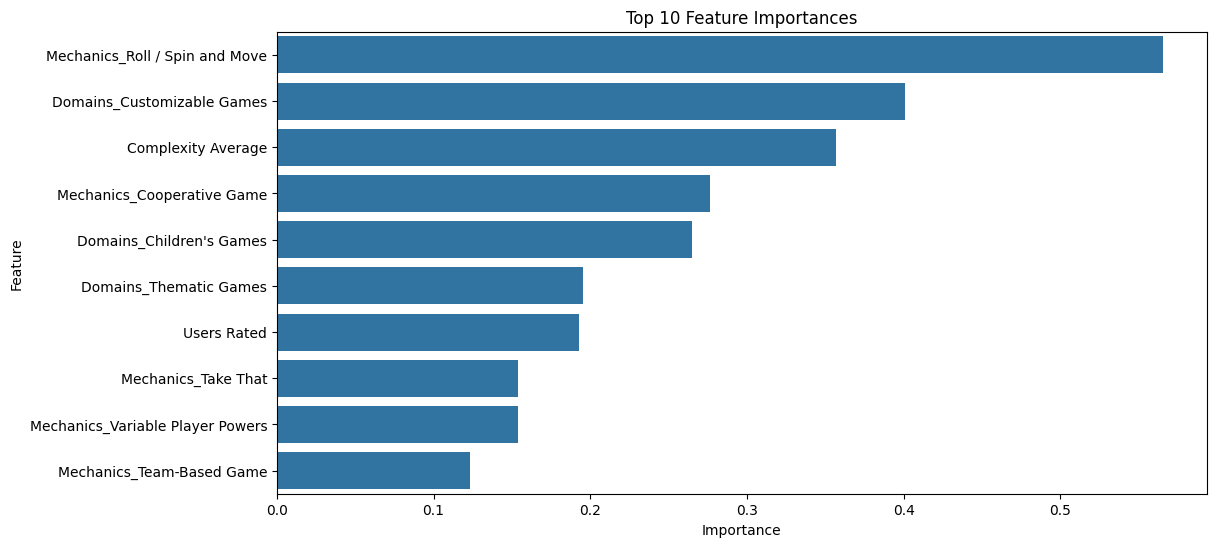

In [ ]:
# Baseline Feature Importance
bl_importances = np.abs(bl_model.coef_)
feat_names = X.columns
bl_feat_importance = pd.DataFrame({'Feature': feat_names, 'Importance': bl_importances})
bl_feat_importance = bl_feat_importance.sort_values(by='Importance', ascending=False)
print("Baseline Feature Importances:")
print(bl_feat_importance)
plt.figure(figsize=(12,6))
sns.barplot(data=bl_feat_importance.head(10), x='Importance', y='Feature')
plt.title('Top 10 Feature Importances')
plt.show()

## Ridge Regression

In [ ]:
# Model Training (Ridge Regression)
# Impute missing values
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)
ridge_model = Ridge()
ridge_model.fit(X_imputed, y_train)

# Model Evaluation for Ridge
y_ridge_pred = ridge_model.predict(X_test_imputed)
print("Ridge Model Evaluation:")
print("Mean Absolute Error:", mean_absolute_error(y_test, y_ridge_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_ridge_pred))
print("R^2 Score:", r2_score(y_test, y_ridge_pred))
print("Cross-Validation Scores (R^2):", cross_val_score(ridge_model, X_imputed, y_train, cv=5))

Ridge Model Evaluation:
Mean Absolute Error: 0.5690166830189299
Mean Squared Error: 0.5812490388266369
R^2 Score: 0.35848736336061515
Cross-Validation Scores (R^2): [0.37869169 0.38697024 0.36661572 0.37842516 0.38381549]


## Feature Importance (Ridge Regression)

Ridge Feature Importances:
                                    Feature  Importance
19           Mechanics_Roll / Spin and Move    0.564727
34               Domains_Customizable Games    0.398713
6                        Complexity Average    0.356744
18               Mechanics_Cooperative Game    0.276224
32                 Domains_Children's Games    0.264384
30                   Domains_Thematic Games    0.195082
5                               Users Rated    0.192893
24                      Mechanics_Take That    0.153779
10         Mechanics_Variable Player Powers    0.153703
25                Mechanics_Team-Based Game    0.122954
23                Mechanics_Auction/Bidding    0.115349
12                     Mechanics_Simulation    0.114563
20                  Mechanics_Area Movement    0.102719
22                  Mechanics_Action Points    0.100142
13                  Mechanics_Card Drafting    0.089244
11                   Mechanics_Hexagon Grid    0.088137
7                    

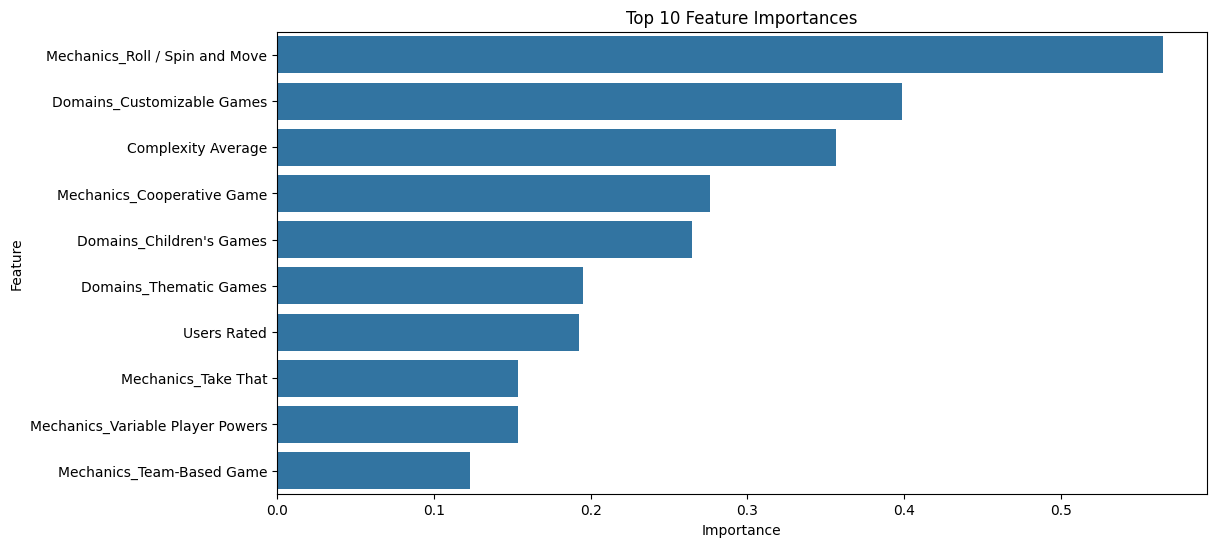

In [ ]:
# Feature Importance for Ridge
ridge_importances = np.abs(ridge_model.coef_)
ridge_feat_importance = pd.DataFrame({'Feature': feat_names, 'Importance': ridge_importances})
ridge_feat_importance = ridge_feat_importance.sort_values(by='Importance', ascending=False)
print("Ridge Feature Importances:")
print(ridge_feat_importance)
plt.figure(figsize=(12,6))
sns.barplot(data=ridge_feat_importance.head(10), x='Importance', y='Feature')
plt.title('Top 10 Feature Importances')
plt.show()

## Lasso Regression

In [ ]:
# Model Training (Lasso Regression)
lasso_model = Lasso()
lasso_model.fit(X_imputed, y_train)

# Model Evaluation for Lasso
y_lasso_pred = lasso_model.predict(X_test_imputed)
print("Lasso Model Evaluation : ")
print("Mean Absolute Error : ", mean_absolute_error(y_test, y_lasso_pred))
print("Mean Squared Error : ", mean_squared_error(y_test, y_lasso_pred))
print("R^2 Score : ", r2_score(y_test, y_lasso_pred))
print("Cross-Validation Scores (R^2) : ", cross_val_score(lasso_model, X_imputed, y_train, cv=5))

Lasso Model Evaluation : 
Mean Absolute Error :  0.7207065366368032
Mean Squared Error :  0.8664729254169136
R^2 Score :  0.04369161266409616
Cross-Validation Scores (R^2) :  [0.04054837 0.04805777 0.05849517 0.05771409 0.05417354]


## Feature Importance (Lasso Regression)

Lasso Feature Importances:
                                    Feature  Importance
0                            Year Published    0.003698
3                                 Play Time    0.000504
26                         Mechanics_Memory    0.000000
20                  Mechanics_Area Movement    0.000000
21  Mechanics_Simultaneous Action Selection    0.000000
22                  Mechanics_Action Points    0.000000
23                Mechanics_Auction/Bidding    0.000000
24                      Mechanics_Take That    0.000000
25                Mechanics_Team-Based Game    0.000000
27                         Domains_Wargames    0.000000
18               Mechanics_Cooperative Game    0.000000
28                   Domains_Strategy Games    0.000000
29                     Domains_Family Games    0.000000
30                   Domains_Thematic Games    0.000000
31                   Domains_Abstract Games    0.000000
32                 Domains_Children's Games    0.000000
33                   

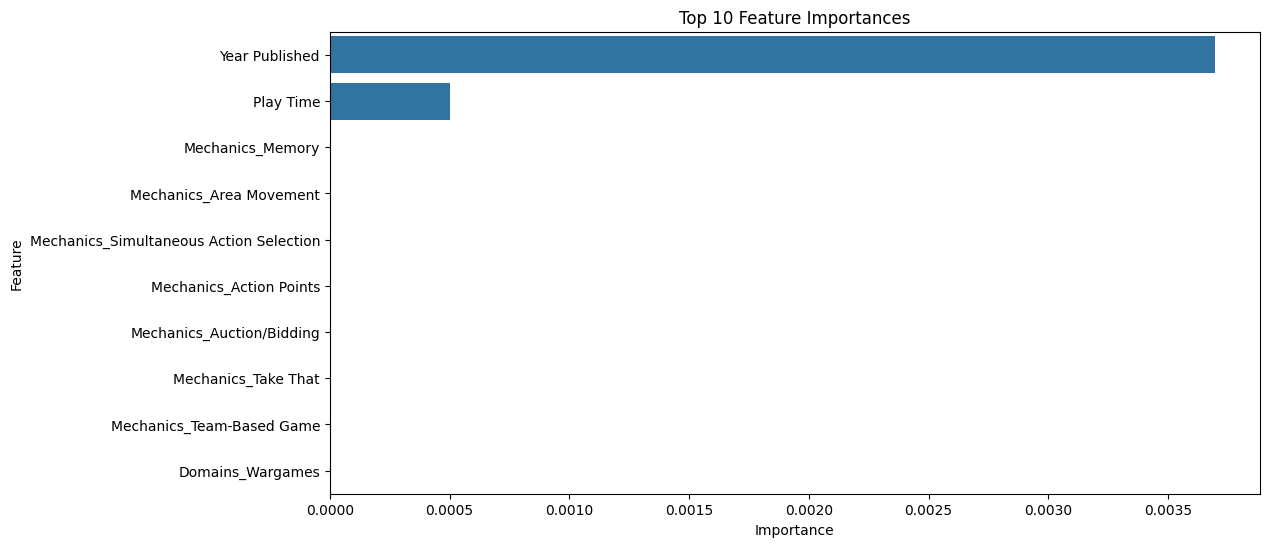

In [ ]:
# Feature Importance for Lasso
lasso_importance= np.abs(lasso_model.coef_)
lasso_feat_importance = pd.DataFrame({'Feature': feat_names, 'Importance': lasso_importance})
lasso_feat_importance = lasso_feat_importance.sort_values(by='Importance', ascending=False)
print("Lasso Feature Importances:")
print(lasso_feat_importance)
plt.figure(figsize=(12,6))
sns.barplot(data=lasso_feat_importance.head(10), x='Importance', y='Feature')
plt.title('Top 10 Feature Importances')
plt.show()

## Random Forest

In [ ]:
# Model Training (Random Forest)
rf = RandomForestRegressor(random_state=6375)
# Parameter grid for GridSearchCV
para_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}
rf_grid = GridSearchCV(rf, para_grid_rf, cv=5, n_jobs=-1, scoring='r2')
rf_grid.fit(X_train, y_train)
# best estimator by grid search
rf = rf_grid.best_estimator_
print("Best RandomForest params:", rf_grid.best_params_)

# Random Forest model with best parameters
rfbest = rf_grid.best_estimator_
rfbest.fit(X_train, y_train)
# Model Evaluation
y_pred = rfbest.predict(X_test)
print("Model Evaluation:")
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R^2 Score:", r2_score(y_test, y_pred))
print("Cross-Validation Scores (R^2):", cross_val_score(rfbest, X, y, cv=5))

Best RandomForest params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Model Evaluation:
Mean Absolute Error: 0.4651057730614516
Mean Squared Error: 0.4035144421953175
R^2 Score: 0.5546493904620526
Cross-Validation Scores (R^2): [0.39364971 0.47905182 0.49560877 0.45399978 0.14630093]


## Feature Importance (Random Forest)

Feature Importances:
                                    Feature  Importance
0                            Year Published    0.226746
6                        Complexity Average    0.209787
5                               Users Rated    0.112371
3                                 Play Time    0.073332
4                                   Min Age    0.063018
2                               Max Players    0.042375
19           Mechanics_Roll / Spin and Move    0.035539
1                               Min Players    0.033995
27                         Domains_Wargames    0.018927
28                   Domains_Strategy Games    0.016627
10         Mechanics_Variable Player Powers    0.014619
7                    Mechanics_Dice Rolling    0.013589
12                     Mechanics_Simulation    0.011586
32                 Domains_Children's Games    0.010233
11                   Mechanics_Hexagon Grid    0.009951
8                 Mechanics_Hand Management    0.008495
18               Mechanics_

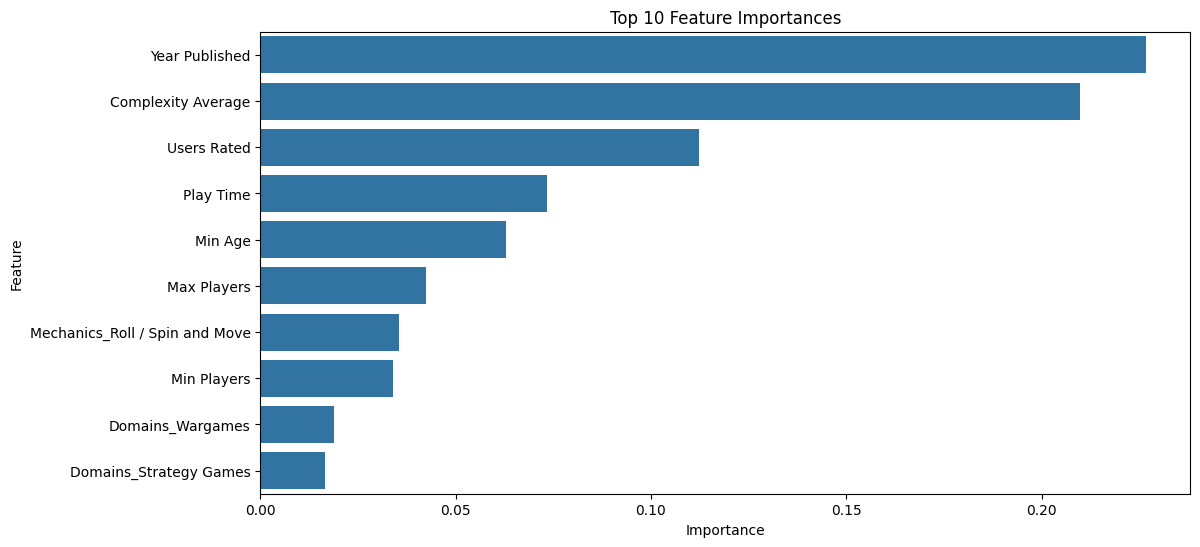

In [ ]:
# Feature Importance
feat_names = list(X.columns)
imp = rfbest.feature_importances_
feat_importance = pd.DataFrame({'Feature': feat_names, 'Importance': imp})
feat_importance = feat_importance.sort_values(by='Importance', ascending=False)
print("Feature Importances:")
print(feat_importance)
plt.figure(figsize=(12,6))
sns.barplot(data=feat_importance.head(10), x='Importance', y='Feature')
plt.title('Top 10 Feature Importances')
plt.show()

## Gradient Boosting

In [ ]:
# Model Training (Gradient Boosting)
gb_model = HistGradientBoostingRegressor(random_state=6375)

# Grid Search for Hyperparameter Tuning
para_grid_gb = {
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5, 10],
    'min_samples_leaf': [20, 50],
    'max_iter': [100, 200]
}
gb_grid = GridSearchCV(gb_model, para_grid_gb, cv=5, n_jobs=-1, scoring='r2')
gb_grid.fit(X_train, y_train)
# Best estimator by grid search
gb_model = gb_grid.best_estimator_
print("Best Gradient Boosting params:", gb_grid.best_params_)
# Gradient Boosting model with best parameters
gb_model_best = gb_grid.best_estimator_
gb_model_best.fit(X_train, y_train)
# Model Evaluation for Gradient Boosting
y_gb_pred = gb_model_best.predict(X_test)
print("Gradient Boosting Model Evaluation:")
print("Mean Absolute Error:", mean_absolute_error(y_test, y_gb_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_gb_pred))
print("R^2 Score:", r2_score(y_test, y_gb_pred))
print("Cross-Validation Scores (R^2):", cross_val_score(gb_model, X, y, cv=5))


Best Gradient Boosting params: {'learning_rate': 0.1, 'max_depth': 5, 'max_iter': 200, 'min_samples_leaf': 20}
Gradient Boosting Model Evaluation:
Mean Absolute Error: 0.461639475437327
Mean Squared Error: 0.4022046982250239
R^2 Score: 0.556094928005481
Cross-Validation Scores (R^2): [0.41671743 0.47069293 0.47914567 0.44553872 0.32677221]


## Feature Importance for Gradient Boosting

Gradient Boosting Feature Importances:
                                    Feature  Importance
0                            Year Published    0.459721
6                        Complexity Average    0.270712
5                               Users Rated    0.098514
2                               Max Players    0.024197
19           Mechanics_Roll / Spin and Move    0.021341
27                         Domains_Wargames    0.012018
3                                 Play Time    0.009759
4                                   Min Age    0.005576
1                               Min Players    0.005252
12                     Mechanics_Simulation    0.003359
10         Mechanics_Variable Player Powers    0.003058
31                   Domains_Abstract Games    0.002210
11                   Mechanics_Hexagon Grid    0.002183
13                  Mechanics_Card Drafting    0.001840
7                    Mechanics_Dice Rolling    0.001609
25                Mechanics_Team-Based Game    0.001377
9        

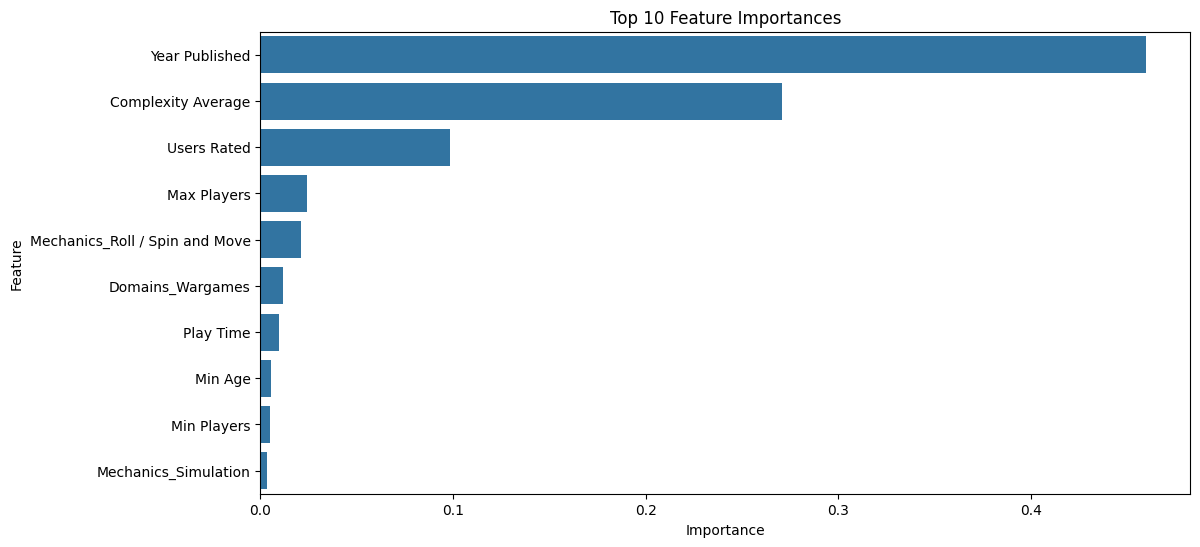

In [ ]:
perm_result = permutation_importance(gb_model_best, X_test, y_test, n_repeats=10, random_state=6375, n_jobs=-1)
gb_feat_importance = pd.DataFrame({'Feature': feat_names, 'Importance': perm_result.importances_mean})
gb_feat_importance = gb_feat_importance.sort_values(by='Importance', ascending=False)
print("Gradient Boosting Feature Importances:")
print(gb_feat_importance)
plt.figure(figsize=(12,6))
sns.barplot(data=gb_feat_importance.head(10), x='Importance', y='Feature')
plt.title('Top 10 Feature Importances')
plt.show()

# Model Comparison (Without BGG RANK)

Model Comparison Summary:
Baseline Linear Regression - Mean R^2: 0.4763, Std: 0.1690
Random Forest - Mean R^2: 0.8079, Std: 0.1075
Ridge Regression - Mean R^2: 0.6222, Std: 0.0132
Lasso Regression - Mean R^2: 0.0518, Std: 0.0067
Gradient Boosting - Mean R^2: 0.9221, Std: 0.0617


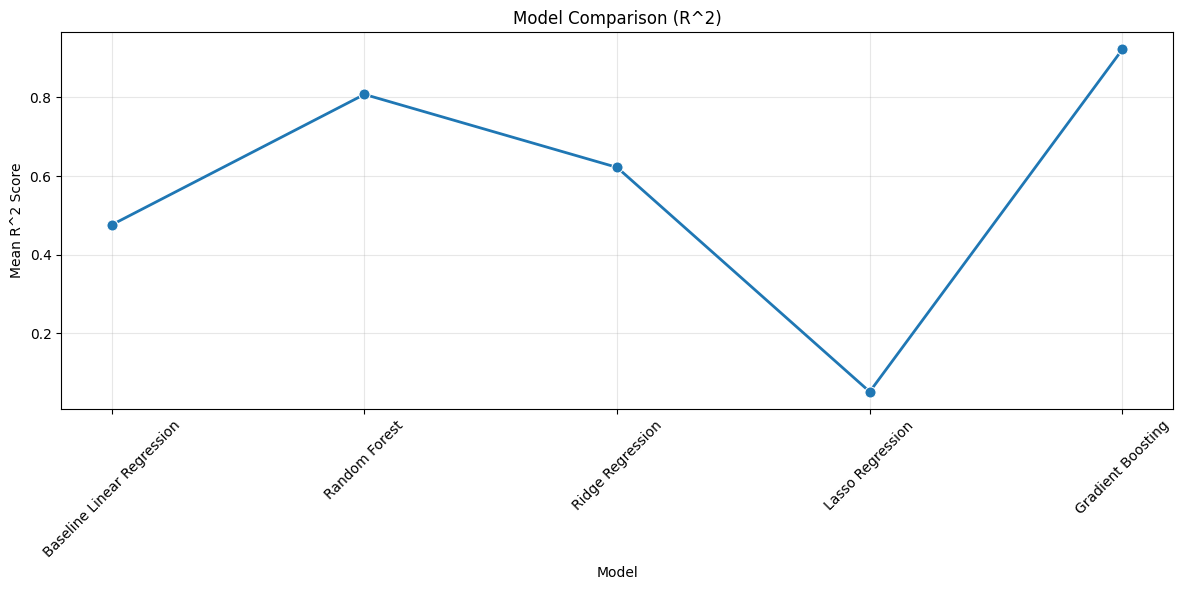

In [ ]:
# Model Comparison
def compare_models(models, X, y, X_imputed=None, y_train=None, cv=5):
    model_names = []
    mean_r2_scores = []
    std_r2_scores = []

    print("Model Comparison Summary:")
    for name, model in models.items():
        # Using imputed data for Ridge/Lasso, original data for others
        if name in ['Ridge Regression', 'Lasso Regression']:
            X_eval = X_imputed
            y_eval = y_train
        else:
            X_eval = X
            y_eval = y

        scores = cross_val_score(model, X_eval, y_eval, cv=cv)
        model_names.append(name)
        mean_r2_scores.append(np.mean(scores))
        std_r2_scores.append(np.std(scores))
        print(f"{name} - Mean R^2: {np.mean(scores):.4f}, Std: {np.std(scores):.4f}")

    # Creating DataFrame for visualization
    model_comp_df = pd.DataFrame({
        'Model': model_names,
        'Mean R^2': mean_r2_scores,
        'Std R^2': std_r2_scores
    })

    return model_comp_df

# Visualize model comparison
def model_comp_graph(model_comp_df):
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=model_comp_df, x='Model', y='Mean R^2', marker='o', linewidth=2, markersize=8)
    plt.title('Model Comparison (R^2)')
    plt.xlabel('Model')
    plt.ylabel('Mean R^2 Score')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# model dictionary
models = {
    'Baseline Linear Regression': bl_model,
    'Random Forest': rfbest,
    'Ridge Regression': ridge_model,
    'Lasso Regression': lasso_model,
    'Gradient Boosting': gb_model_best
}

# Compare models
model_comp = compare_models(models, X, y, X_imputed=X_imputed, y_train=y_train, cv=5)

# Plot comparison
model_comp_graph(model_comp)